# A Treasure Hunt 

Your task this week is to guide our agent to a treasure hidden at the bottom of the ocean.

The task is presented as a game and the mechanics have been implemented for you in the [treasurehunt.ipynb](./treasurehunt.ipynb) notebook.   
A couple of utility functions have also been defined for you in  [utils.ipynb](./utils.ipynb).  You are required to use both of them in your implementation.

This is the only notebook you need to submit when you complete your assignment.

Let's first import all we need before we get started. Make sure you run the code cell below everytime you start working on this notebook.


In [ ]:
%run treasurehunt.ipynb

## Discovering the Game
You can play the game in discovery mode (without help) by running the code cell below.

Click on the 'SONAR' button to start taking sonar measurements.  When you are ready to make a decision and dive, click on the 'DIVE' button.  

In [ ]:
treasurehunt(10, "discovery")  # You can change 10 to any positive integer to change the number of rows and columns

## Guiding our Agent
Your task is to help our player/agent find the treasure more reliably by implementing the two methods in the Belief class definition below.  

### Updating the beliefs
The Belief class is used to track the belief distribution (where we think the treasure is) based on the sonar sensing evidence we have so far.  
The distribution is initialized to a uniform distribution in the \__init\__ method.  
By filling in your code in the _update_ method, you will update that distribution with each evidence.
Don't forget to normalize!  


### Recommending Next Sonar Measurement
The _recommend_sensing method_ returns the position where we should take the next sonar measurement in the grid.  
The position should be the most promising unobserved location.  
If all remaining unobserved locations have a probability of 0, the method should return the unobserved location that is closest to the (observed) location with the highest probability.  
The recommended location is displayed in purple on the grid - as shown in the screenshots below.  If there are no remaining unobserved locations,  the method will return the (observed) location with the highest probability.  Note that you may not be able to 'see' the sonar color after sensing if the same location is recommended next.  That is ok because the goal here is to figure out where the treasure is without sensing everywhere.


Once you have filled in your code for the _update_ method and executed the code cell, you can see the distribution on the grid.
Just start the game in 'guided' mode as shown below.
Note that the player should be able to sense the same location more than once. 


In [ ]:
class Belief(object):

    """
    Belief class used to track the belief distribution based on the
    sensing evidence we have so far.
    Arguments:
    size (int): the number of rows/columns in the grid

    Attributes:
    open (set of tuples): set containing all the positions that have not
        been observed so far.
    current_distribution (dictionary): probability distribution based on
        the evidence observed so far.
        The keys of the dictionary are the possible grid positions
        The values represent the (conditional) probability that the
        treasure is found at that position given the evidence
        (sensor data) observed so far.
    """

    def __init__(self, size):
        # Initially all positions are open - have not been observed
        self.open = {(x, y) for x in range(size) for y in range(size)}
        # Initialize to a uniform distribution
        self.current_distribution = {pos: 1 / (size ** 2) for pos in self.open}


    def update(self, color, sensor_position, model):
        """
        Update the belief distribution based on new evidence:  our agent
        detected the given color at sensor location: sensor_position.
        :param color: (string) color detected
        :param sensor_position: (tuple) position of the sensor
        :param model (Model object) models the relationship between the
             treasure location and the sensor data
        :return: None
        """
        # Iterate over ALL positions in the grid and update the
        # probability of finding the treasure at that position - given
        # the new evidence.
        # The probability of the evidence given the Manhattan distance
        # to the treasure is given by calling model.pcolorgivendist.
        # Don't forget to normalize.
        # Don't forget to update self.open since sensor_position has
        # now been observed.
        self.open.discard(sensor_position)

        sx, sy = sensor_position
        for pos in self.current_distribution:
            tx, ty = pos 
            distance = abs(sx - tx) + abs(sy - ty) 
            probability = model.pcolorgivendist(color, distance)
            self.current_distribution[pos] *= probability 

        # normalize
        total = sum(self.current_distribution.values())
        if total != 0:
            for pos in self.current_distribution:
                self.current_distribution[pos] /= total

    def recommend_sensing(self):
        """
        Recommend where we should take the next measurement in the grid.
        The position should be the most promising unobserved location.
        If all remaining unobserved locations have a probability of 0,
        return the unobserved location that is closest to the (observed)
        location with the highest probability.
        If there are no remaining unobserved locations return the
        (observed) location with the highest probability.

        :return: tuple representing the position where we should take
            the next measurement
        """
        # Enter your code and remove the statement below
        if not self.open:
            return max(self.current_distribution, key = lambda pos: self.current_distribution[pos])

        best_open = max(self.open, key = lambda pos: self.current_distribution[pos])

        if self.current_distribution[best_open] == 0:
            best_overall = max(self.current_distribution,
                               key = lambda pos: self.current_distribution[pos])
            return closest_point(best_overall, self.open)

        return best_open

In [ ]:
treasurehunt(8, "guided")

## Testing
We set the random seed here for testing to get the same sequence of random numbers. This will ensure the reproducibility of the results.   
Note that the game will be boring when we do that - since the treasure will always be in the same location.  
Run the code cells below and select the positions shown in the 3 scenarios below - in order - in sonar mode. The distribution you get after sensing the numbered positions shown should match.  The order of the sensing should also reflect  the recommendation returned by the _recommend_sensing_ mrthod.  

### Scenario 1

In [ ]:
random.seed(5)
treasurehunt(8, "guided")

Here's the expected distribution for Scenario 1:
<div> 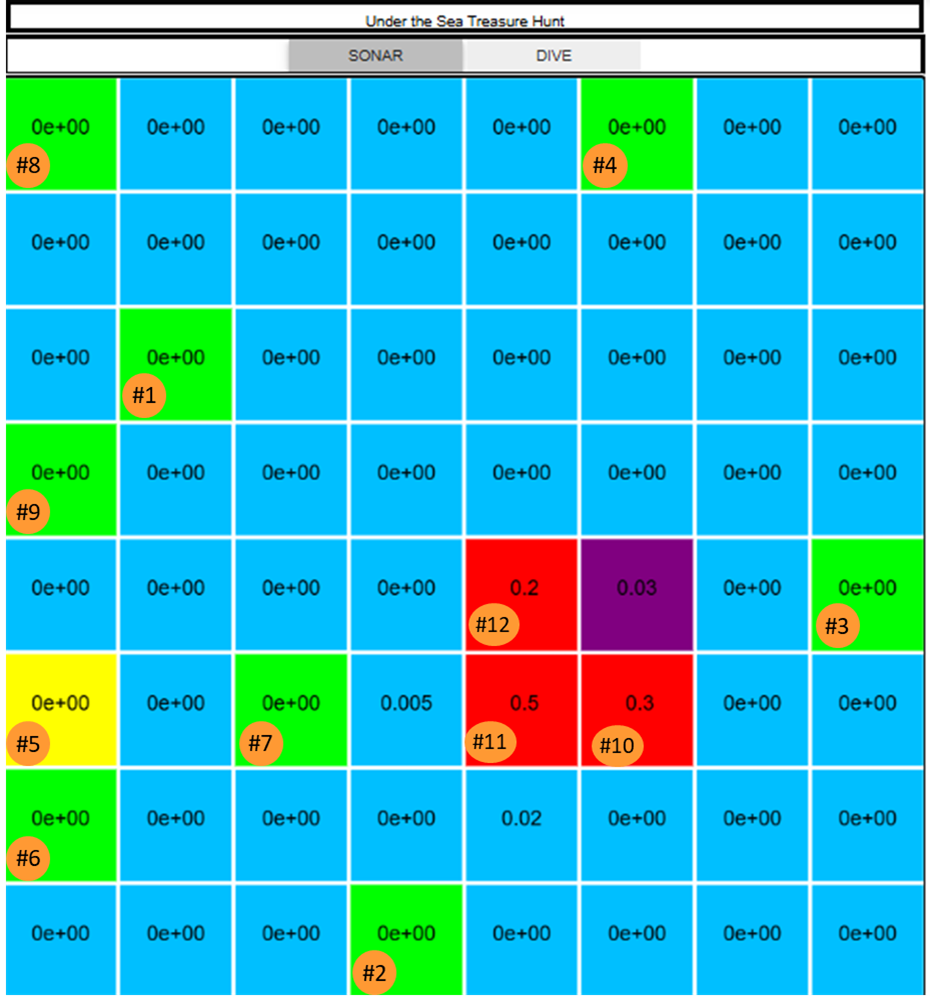 </div>



### Scenario 2

In [ ]:
random.seed(5)
treasurehunt(8, "guided")

Here's the expected distribution for Scenario 2:
<div> 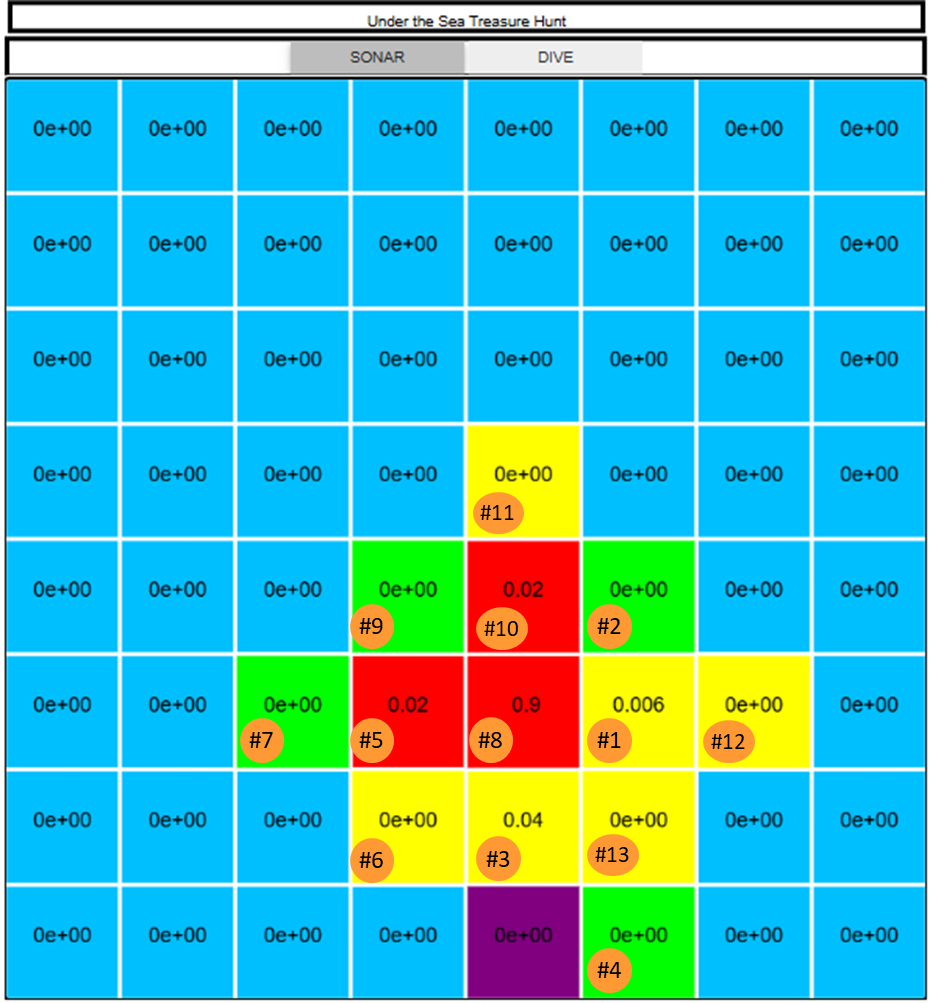 </div>

### Scenario 3

In [ ]:
random.seed(5)
treasurehunt(3, "guided")

Here's the expected distribution for Scenario 3: 
<div> 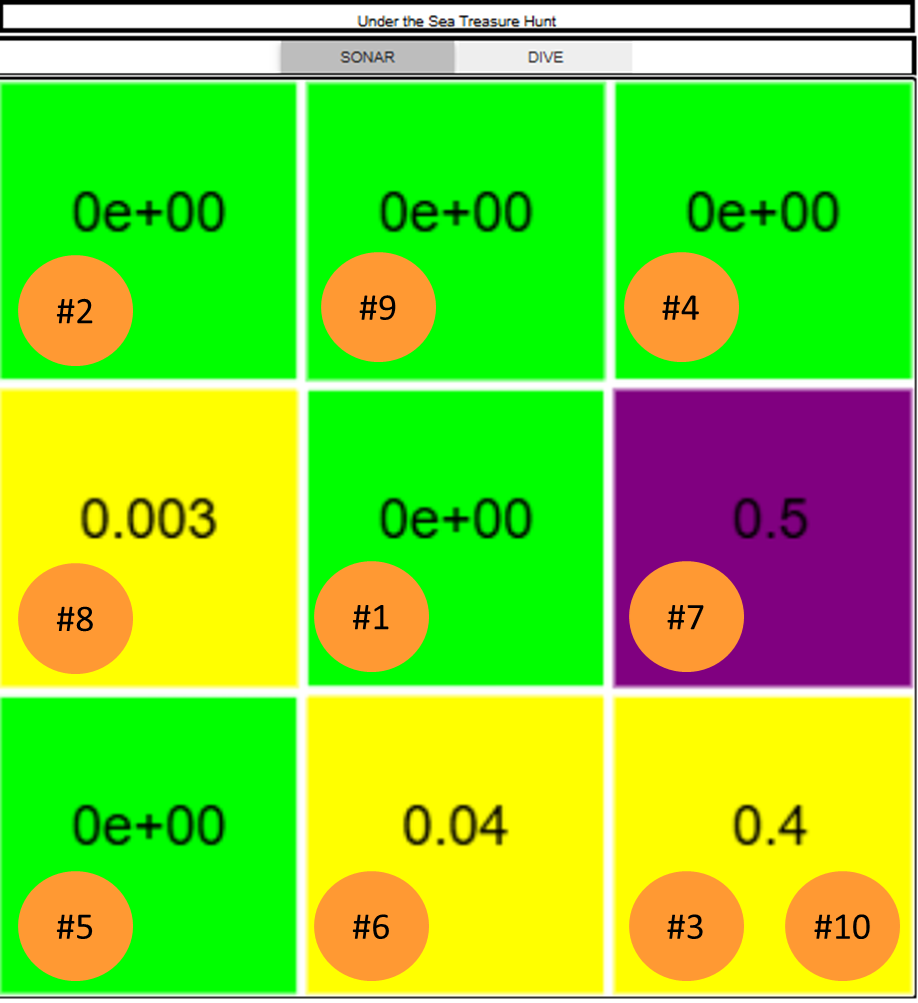 </div>